# AE Anomaly Detection: Credit Card Fraud
**Prof. Ing. Carlos Andrés Sierra, M.Sc. — Universidad Distrital FJC**

Practical example from the *Deep Learning: Advanced Topics* slides — *Autoencoders & Anomaly Detection* section.

Autoencoder-based anomaly detection on the **Credit Card Fraud** dataset (Kaggle / ULB, 284 807 transactions, 0.17 % fraud):

| Step | Description |
|------|-------------|
| **Preprocessing** | StandardScale `Amount`; train AE on **normal transactions only** |
| **Step 1** | Scatter plot of reconstruction errors — normal vs. fraud |
| **Step 2** | Threshold at 95th percentile; precision / recall / F1 |
| **Step 3** | UMAP 2-D projection of latent codes; colour by fraud label |

> **Expected result:** fraud transactions cluster in high-error regions and appear as distinct outliers in the 2-D latent projection.  
> **Dataset note:** if `creditcard.csv` is not found locally, a synthetic dataset with identical structure and similar statistics is generated automatically.

---
## Section 1 — Install & Import Libraries

In [1]:
import sys, subprocess

_pkgs = [
    'torch', 'numpy<2', 'pandas', 'matplotlib',
    'scikit-learn', 'tqdm', 'umap-learn',
]
subprocess.check_call(
    [sys.executable, '-m', 'pip', 'install', '--quiet', '--prefer-binary'] + _pkgs
)
print('Packages ready.')

Packages ready.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
)
from tqdm import tqdm

torch.manual_seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cpu


---
## Section 2 — Load & Explore the Dataset
The **Credit Card Fraud** dataset (ULB / Kaggle) contains:
- 284 807 transactions, 492 fraud (0.173 %)
- `V1`–`V28`: PCA-transformed (already normalised at source)
- `Amount`: raw transaction value (scaled below)
- `Time`: seconds since first transaction (dropped — not predictive)
- `Class`: 0 = normal, 1 = fraud

In [3]:
DATA_PATH = './data/creditcard.csv'
SYNTHETIC = False

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f'Loaded real dataset from {DATA_PATH}: {len(df):,} rows')
else:
    # Try OpenML (requires internet access, no login needed)
    try:
        from sklearn.datasets import fetch_openml
        print('creditcard.csv not found locally — downloading from OpenML ...')
        raw = fetch_openml(data_id=1597, as_frame=True, parser='auto')
        df = raw.frame.copy()
        df['Class'] = df['Class'].astype(str).str.strip().astype(int)
        os.makedirs('./data', exist_ok=True)
        df.to_csv(DATA_PATH, index=False)
        print(f'Downloaded and cached: {len(df):,} rows → {DATA_PATH}')
    except Exception as exc:
        print(f'OpenML download failed ({exc}).\n'
              f'Tip: download creditcard.csv from '
              f'https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud '
              f'and place it in ./data/\n'
              f'Generating synthetic data instead ...\n')
        rng = np.random.RandomState(42)
        N_NORMAL, N_FRAUD, N_FEAT = 284_315, 492, 28
        # Fraud has a consistent out-of-distribution shift in PCA space
        fraud_shift = rng.randn(N_FEAT) * 3.0
        X_n = rng.randn(N_NORMAL, N_FEAT)
        X_f = rng.randn(N_FRAUD,  N_FEAT) * 1.8 + fraud_shift
        amt_n = rng.exponential(88.0,  N_NORMAL)
        amt_f = rng.exponential(120.0, N_FRAUD)
        X   = np.vstack([X_n, X_f])
        amt = np.concatenate([amt_n, amt_f])
        y   = np.array([0] * N_NORMAL + [1] * N_FRAUD)
        idx = rng.permutation(len(y))
        X, amt, y = X[idx], amt[idx], y[idx]
        df = pd.DataFrame(X, columns=[f'V{i}' for i in range(1, N_FEAT + 1)])
        df['Amount'] = amt
        df['Class']  = y
        SYNTHETIC = True
        print(f'Synthetic dataset: {len(df):,} rows  |  '
              f'{int(y.sum()):,} fraud  ({y.mean()*100:.3f} %)')

print(f'\nShape : {df.shape}')
print(f'Fraud : {int(df["Class"].sum()):,} / {len(df):,}  ({df["Class"].mean()*100:.3f} %)')
print(df.head(3))

creditcard.csv not found locally — downloading from OpenML ...


/Users/casv-mac/.pyenv/versions/ml_old/lib/python3.11/site-packages/sklearn/datasets/_openml.py:109: UserWarning: A network error occurred while downloading https://api.openml.org/api/v1/json/data/1597. Retrying...
  warn(


OpenML download failed (<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1016)>).
Tip: download creditcard.csv from https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud and place it in ./data/
Generating synthetic data instead ...

Synthetic dataset: 284,807 rows  |  492 fraud  (0.173 %)

Shape : (284807, 30)
Fraud : 492 / 284,807  (0.173 %)
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.817016 -1.792558  1.310090 -0.266389 -1.476916 -0.000500  1.375698   
1  0.132735  1.318696 -0.526113 -0.478794  0.077494  1.376628  0.127433   
2  0.053019 -0.313907 -0.439869  0.971005  0.549645  0.638591  0.655272   

         V8        V9       V10  ...       V21       V22       V23       V24  \
0 -1.498298 -1.294633  0.351419  ...  0.596509  0.370812 -0.958120 -0.421643   
1 -1.530161  1.237764  0.271850  ... -0.102151  0.855159 -0.808222  1.829167   
2 -1.565731  0.066834  0.605458  ...  0

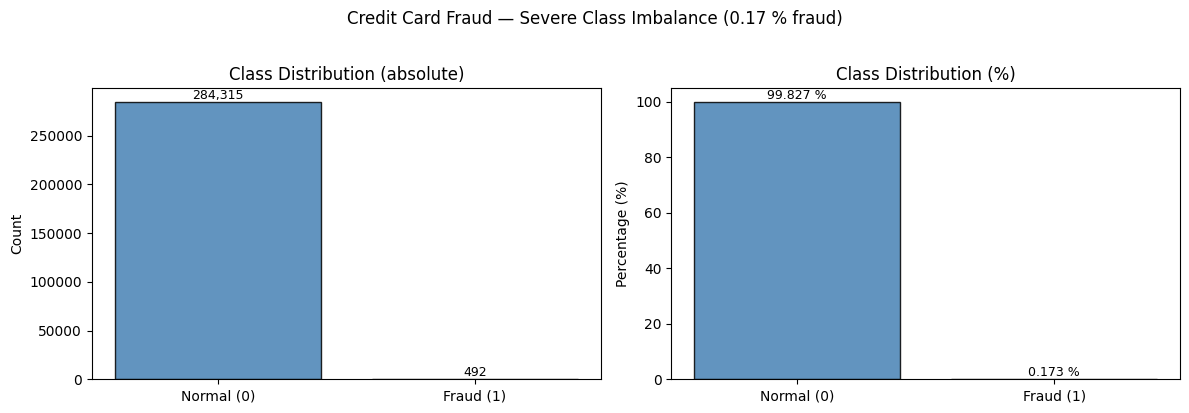

In [4]:
# Class distribution
counts = df['Class'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, vals, ylabel, fmt in [
    (axes[0], counts.values,
     'Count', lambda v: f'{v:,}'),
    (axes[1], counts.values / len(df) * 100,
     'Percentage (%)', lambda v: f'{v:.3f} %'),
]:
    bars = ax.bar(['Normal (0)', 'Fraud (1)'], vals,
                  color=['steelblue', 'firebrick'], edgecolor='black', alpha=0.85)
    ax.set_ylabel(ylabel)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.01,
                fmt(v), ha='center', fontsize=9)

axes[0].set_title('Class Distribution (absolute)')
axes[1].set_title('Class Distribution (%)')
plt.suptitle('Credit Card Fraud — Severe Class Imbalance (0.17 % fraud)', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

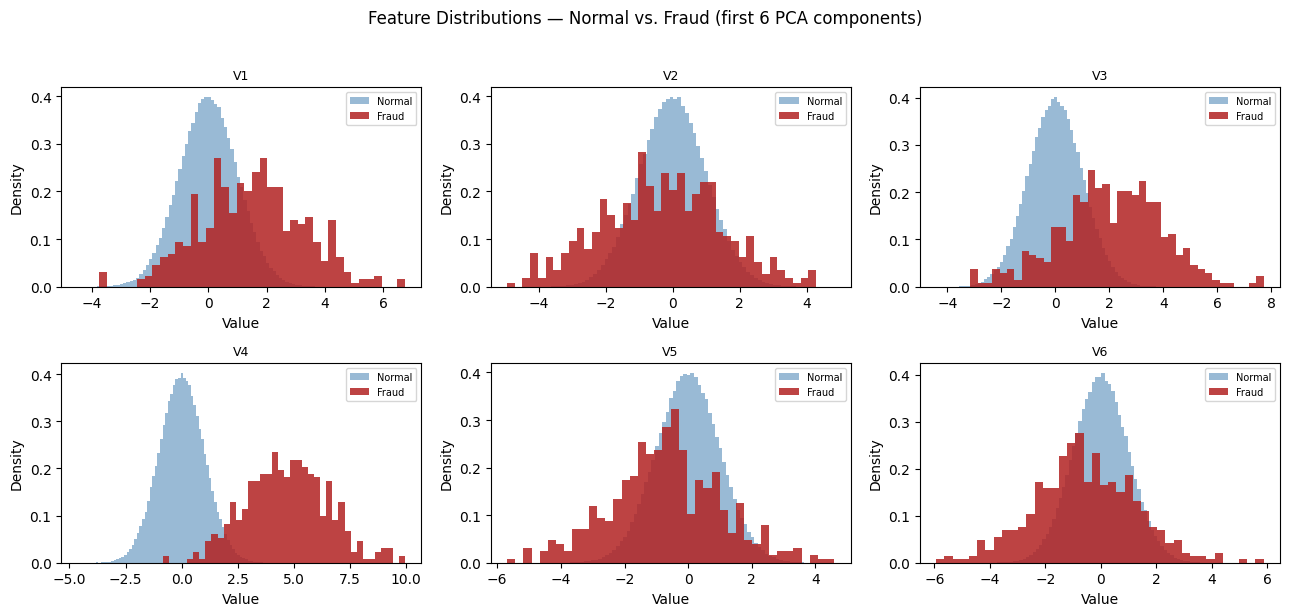

In [5]:
# Feature distributions: first 6 PCA components
fig, axes = plt.subplots(2, 3, figsize=(13, 6))

for ax, col in zip(axes.flat, [f'V{i}' for i in range(1, 7)]):
    normal_vals = df.loc[df['Class'] == 0, col]
    fraud_vals  = df.loc[df['Class'] == 1, col]
    ax.hist(normal_vals, bins=80, color='steelblue', alpha=0.55,
            density=True, label='Normal')
    ax.hist(fraud_vals,  bins=40, color='firebrick', alpha=0.85,
            density=True, label='Fraud')
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')

plt.suptitle('Feature Distributions — Normal vs. Fraud (first 6 PCA components)', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 3 — Preprocessing & Data Splits

**Key decisions:**
1. Drop `Time` — seconds-offset is not meaningful once the PCA features are present.
2. Scale `Amount` with `StandardScaler` — the only feature that is not PCA-normalised.
3. Split the **normal class only** into train / val — the AE never sees fraud.
4. Test set = held-out normal slice + **all fraud** (for evaluation).

```
Normal transactions ──► 70 % train  (AE training)
                    ├─► 15 % val    (threshold calibration)
                    └─► 15 % test   ┐
Fraud  transactions (all)  ─────────┘  (evaluation)
```

In [6]:
FEATURE_COLS = [f'V{i}' for i in range(1, 29)] + ['Amount']
INPUT_DIM    = len(FEATURE_COLS)   # 29

df_proc = df[FEATURE_COLS + ['Class']].copy()

scaler = StandardScaler()
df_proc['Amount'] = scaler.fit_transform(df_proc[['Amount']])

# Split by class
normal = df_proc[df_proc['Class'] == 0][FEATURE_COLS].values.astype(np.float32)
fraud  = df_proc[df_proc['Class'] == 1][FEATURE_COLS].values.astype(np.float32)
print(f'Normal : {len(normal):,}  |  Fraud : {len(fraud):,}  |  Input dim: {INPUT_DIM}')

# 70 / 15 / 15 split on normal only
X_train_n, X_temp    = train_test_split(normal, test_size=0.30, random_state=42)
X_val_n,   X_test_n  = train_test_split(X_temp, test_size=0.50, random_state=42)

# Test set: held-out normal + all fraud
X_test = np.vstack([X_test_n, fraud])
y_test = np.array([0] * len(X_test_n) + [1] * len(fraud), dtype=np.int64)

print(f'Train  (normal only)    : {len(X_train_n):,}')
print(f'Val    (normal only)    : {len(X_val_n):,}')
print(f'Test   (normal + fraud) : {len(X_test):,}  (fraud = {y_test.sum():,})')

# DataLoaders
BATCH_SIZE   = 512
train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train_n)),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(TensorDataset(torch.from_numpy(X_val_n)),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(TensorDataset(torch.from_numpy(X_test)),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print('DataLoaders ready.')

Normal : 284,315  |  Fraud : 492  |  Input dim: 29
Train  (normal only)    : 199,020
Val    (normal only)    : 42,647
Test   (normal + fraud) : 43,140  (fraud = 492)
DataLoaders ready.


---
## Section 4 — Autoencoder Architecture

A **symmetric bottleneck AE** for tabular data:

```
Input (29) ──► [Linear→BN→ReLU] ──► 20 ──► [Linear→BN→ReLU] ──► 12 ──► [Linear] ──► 8  (latent)
                                                                                         │
Output (29) ◄── [Linear←BN←ReLU] ◄── 20 ◄── [Linear←BN←ReLU] ◄── 12 ◄── [Linear] ◄──┘
```

The encoder compresses the **normal-transaction manifold** into 8 dimensions.  
At inference, the reconstruction error (MSE) is the **anomaly score** — high error signals an outlier.

In [7]:
LATENT_DIM = 8


class TabularAE(nn.Module):
    """Symmetric bottleneck Autoencoder for tabular anomaly detection.
    Architecture: input_dim -> 20 -> 12 -> latent_dim -> 12 -> 20 -> input_dim
    """

    def __init__(self, input_dim: int = INPUT_DIM, latent_dim: int = LATENT_DIM):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 20),
            nn.BatchNorm1d(20),
            nn.ReLU(inplace=True),
            nn.Linear(20, 12),
            nn.BatchNorm1d(12),
            nn.ReLU(inplace=True),
            nn.Linear(12, latent_dim),  # no activation on latent
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 12),
            nn.BatchNorm1d(12),
            nn.ReLU(inplace=True),
            nn.Linear(12, 20),
            nn.BatchNorm1d(20),
            nn.ReLU(inplace=True),
            nn.Linear(20, input_dim),   # no activation — MSE on raw values
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(x))

    @torch.no_grad()
    def encode(self, x: torch.Tensor) -> torch.Tensor:
        self.eval()
        return self.encoder(x)


model  = TabularAE(INPUT_DIM, LATENT_DIM).to(DEVICE)
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'TabularAE  |  Input: {INPUT_DIM}  |  Latent: {LATENT_DIM}  |  Params: {params:,}')
print(model)

TabularAE  |  Input: 29  |  Latent: 8  |  Params: 2,061
TabularAE(
  (encoder): Sequential(
    (0): Linear(in_features=29, out_features=20, bias=True)
    (1): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=20, out_features=12, bias=True)
    (4): BatchNorm1d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=12, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=12, bias=True)
    (1): BatchNorm1d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=12, out_features=20, bias=True)
    (4): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=20, out_features=29, bias=True)
  )
)


---
## Section 5 — Train on Normal Transactions Only

The AE is trained to **reconstruct normal transactions with low MSE**.  
Fraud transactions — **never seen** during training — lie outside the learned manifold and will produce **higher reconstruction error**.

In [8]:
EPOCHS    = 40
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=4, min_lr=1e-5
)


def train_epoch(model, loader, opt, crit):
    model.train()
    total = 0.0
    for (x,) in loader:
        x = x.to(DEVICE)
        opt.zero_grad()
        loss = crit(model(x), x)
        loss.backward()
        opt.step()
        total += loss.item() * x.size(0)
    return total / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, crit):
    model.eval()
    total = 0.0
    for (x,) in loader:
        x = x.to(DEVICE)
        total += crit(model(x), x).item() * x.size(0)
    return total / len(loader.dataset)

/Users/casv-mac/.pyenv/versions/ml_old/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
history        = {'train_loss': [], 'val_loss': []}
best_val_loss  = float('inf')
best_state     = None

print(f'Training TabularAE for {EPOCHS} epochs '
      f'on {len(X_train_n):,} normal transactions ...\n')

for epoch in tqdm(range(1, EPOCHS + 1), desc='Training'):
    tr = train_epoch(model, train_loader, optimizer, criterion)
    vl = eval_epoch(model, val_loader,   criterion)
    history['train_loss'].append(tr)
    history['val_loss'].append(vl)
    scheduler.step(vl)
    if vl < best_val_loss:
        best_val_loss = vl
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    if epoch % 10 == 0 or epoch == 1:
        print(f'  Epoch {epoch:3d}/{EPOCHS}  '
              f'train={tr:.6f}  val={vl:.6f}')

model.load_state_dict(best_state)
print(f'\nBest val MSE: {best_val_loss:.6f}')

Training TabularAE for 40 epochs on 199,020 normal transactions ...



Training:   2%|▎         | 1/40 [00:03<02:15,  3.47s/it]

  Epoch   1/40  train=0.866690  val=0.789191


Training:  25%|██▌       | 10/40 [00:31<01:32,  3.10s/it]

  Epoch  10/40  train=0.635688  val=0.633825


...

  Epoch  20/40  train=0.622129  val=0.628338


Training:  75%|███████▌  | 30/40 [01:43<00:34,  3.44s/it]

  Epoch  30/40  train=0.618147  val=0.616806


Training: 100%|██████████| 40/40 [02:15<00:00,  3.40s/it]

  Epoch  40/40  train=0.611278  val=0.613090

Best val MSE: 0.613090


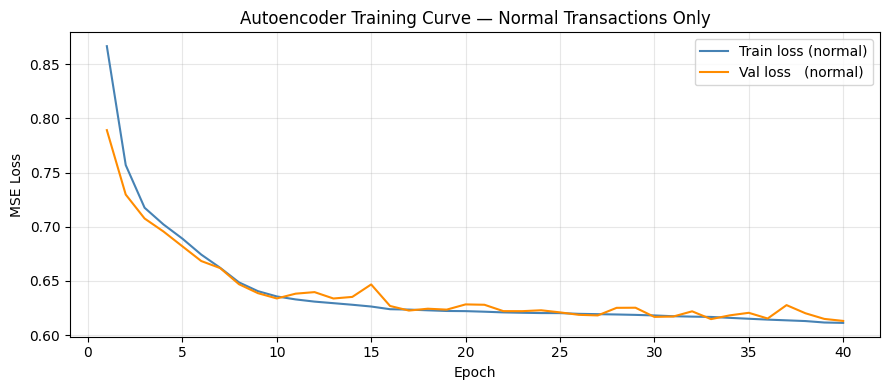

In [10]:
# Training / validation loss curves
fig, ax = plt.subplots(figsize=(9, 4))
eps = range(1, EPOCHS + 1)
ax.plot(eps, history['train_loss'], label='Train loss (normal)', color='steelblue')
ax.plot(eps, history['val_loss'],   label='Val loss   (normal)', color='darkorange')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Autoencoder Training Curve — Normal Transactions Only')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ae_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 6 — Step 1: Reconstruction Error Analysis

Compute the **per-sample reconstruction error** (mean MSE over all 29 features) on the full test set (normal + fraud).  
Fraud samples should show **significantly higher error** because the AE was trained exclusively on the normal manifold.

In [11]:
@torch.no_grad()
def reconstruction_errors(model, X: np.ndarray) -> np.ndarray:
    """Per-sample MSE reconstruction error."""
    model.eval()
    t = torch.from_numpy(X).to(DEVICE)
    return ((t - model(t)) ** 2).mean(dim=1).cpu().numpy()


errors_test   = reconstruction_errors(model, X_test.astype(np.float32))
errors_normal = errors_test[y_test == 0]
errors_fraud  = errors_test[y_test == 1]

print('Reconstruction error statistics:')
for label, arr in [('Normal', errors_normal), ('Fraud ', errors_fraud)]:
    print(f'  {label}  mean={arr.mean():.5f}  '
          f'median={np.median(arr):.5f}  '
          f'95th={np.percentile(arr, 95):.5f}  '
          f'max={arr.max():.5f}')

Reconstruction error statistics:
  Normal  mean=0.61402  median=0.59046  95th=0.97736  max=1.85495
  Fraud   mean=8.95524  median=8.77624  95th=12.59770  max=22.23864


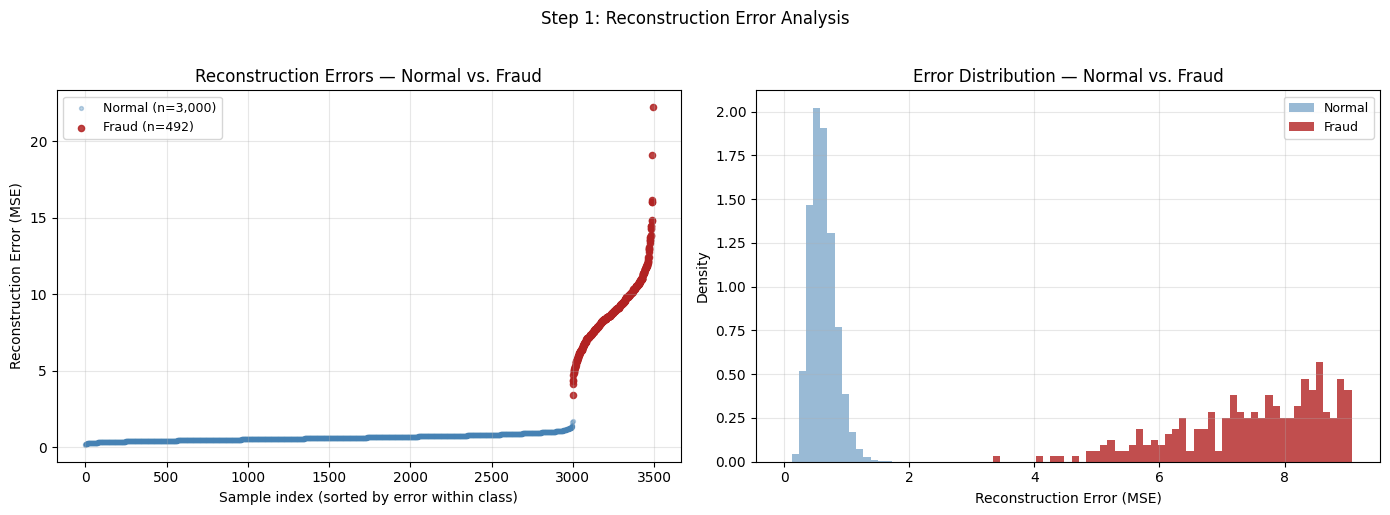

In [12]:
# Scatter + histogram: reconstruction error (normal vs fraud)
rng_plot = np.random.RandomState(0)
n_sub    = min(3000, len(errors_normal))
idx_sub  = np.sort(rng_plot.choice(len(errors_normal), n_sub, replace=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Scatter ──────────────────────────────────────────────────────────────────
x_n = np.arange(n_sub)
x_f = np.arange(n_sub, n_sub + len(errors_fraud))
axes[0].scatter(x_n, np.sort(errors_normal)[idx_sub],
                c='steelblue', s=8, alpha=0.35, label=f'Normal (n={n_sub:,})')
axes[0].scatter(x_f, np.sort(errors_fraud),
                c='firebrick', s=20, alpha=0.85, label=f'Fraud (n={len(errors_fraud):,})')
axes[0].set_xlabel('Sample index (sorted by error within class)')
axes[0].set_ylabel('Reconstruction Error (MSE)')
axes[0].set_title('Reconstruction Errors — Normal vs. Fraud')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# ── Histogram ────────────────────────────────────────────────────────────────
cap  = np.percentile(errors_test, 99.5)
bins = np.linspace(0, cap, 80)
axes[1].hist(errors_normal, bins=bins, color='steelblue', alpha=0.55,
             density=True, label='Normal')
axes[1].hist(errors_fraud,  bins=bins, color='firebrick', alpha=0.8,
             density=True, label='Fraud')
axes[1].set_xlabel('Reconstruction Error (MSE)')
axes[1].set_ylabel('Density')
axes[1].set_title('Error Distribution — Normal vs. Fraud')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Step 1: Reconstruction Error Analysis', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('step1_reconstruction_errors.png', dpi=120, bbox_inches='tight')
plt.show()

/var/folders/bb/bqlj1l1d1z372q0mcl9gyfzm0000gn/T/ipykernel_55186/2267755446.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


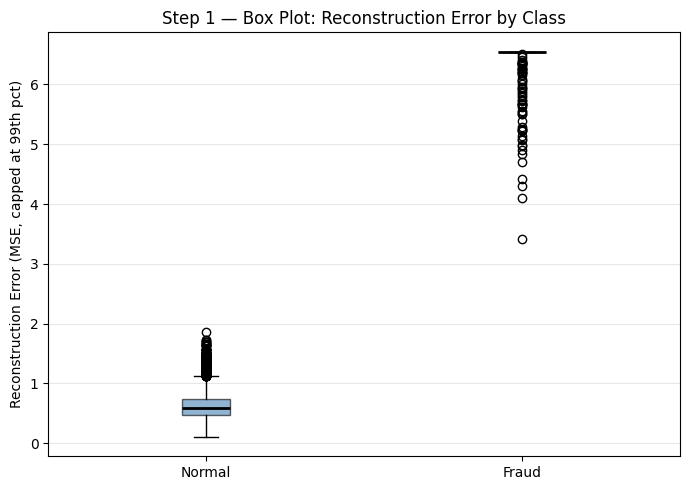

In [13]:
# Box plot — capped at 99th percentile for readability
cap = np.percentile(errors_test, 99)
fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot(
    [np.clip(errors_normal, 0, cap), np.clip(errors_fraud, 0, cap)],
    labels=['Normal', 'Fraud'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
)
bp['boxes'][0].set_facecolor('steelblue');  bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('firebrick'); bp['boxes'][1].set_alpha(0.6)
ax.set_ylabel('Reconstruction Error (MSE, capped at 99th pct)')
ax.set_title('Step 1 — Box Plot: Reconstruction Error by Class')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('step1_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 7 — Step 2: Threshold & Classification Metrics

Set the detection threshold at the **95th percentile** of reconstruction errors on the **validation set** (normal only).  
Samples above the threshold are flagged as fraud.

> Using the *validation* set (not test) for threshold calibration avoids data leakage.

In [14]:
errors_val = reconstruction_errors(model, X_val_n.astype(np.float32))
THRESHOLD  = np.percentile(errors_val, 95)
print(f'Threshold (95th pct of val normal errors): {THRESHOLD:.6f}')

y_pred = (errors_test > THRESHOLD).astype(int)

prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, errors_test)
ap   = average_precision_score(y_test, errors_test)

print(f'\n── Test-Set Results (threshold = {THRESHOLD:.4f}) ──')
print(f'  Precision  : {prec:.4f}')
print(f'  Recall     : {rec:.4f}')
print(f'  F1         : {f1:.4f}')
print(f'  ROC-AUC    : {auc:.4f}')
print(f'  PR-AUC     : {ap:.4f}   ← informative under class imbalance')

Threshold (95th pct of val normal errors): 0.976475

── Test-Set Results (threshold = 0.9765) ──
  Precision  : 0.1864
  Recall     : 1.0000
  F1         : 0.3143
  ROC-AUC    : 1.0000
  PR-AUC     : 1.0000   ← informative under class imbalance


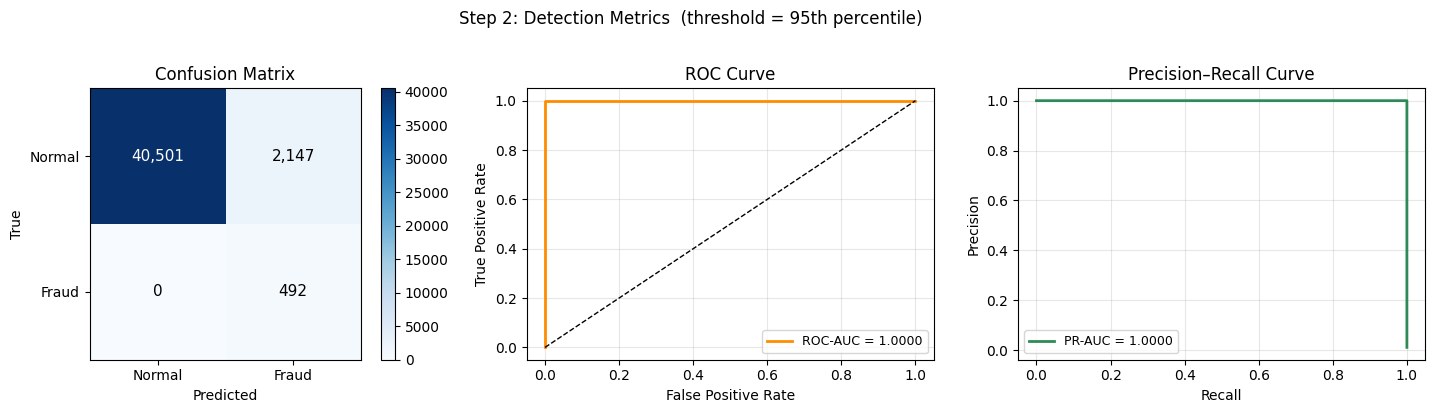

In [15]:
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Confusion matrix
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Normal', 'Fraud'])
axes[0].set_yticklabels(['Normal', 'Fraud'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                     color='white' if cm[i,j] > cm.max() / 2 else 'black',
                     fontsize=11)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, errors_test)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

# Precision-Recall curve (better for imbalanced data)
prec_c, rec_c, _ = precision_recall_curve(y_test, errors_test)
axes[2].plot(rec_c, prec_c, color='seagreen', lw=2, label=f'PR-AUC = {ap:.4f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision–Recall Curve')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.suptitle('Step 2: Detection Metrics  (threshold = 95th percentile)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('step2_metrics.png', dpi=120, bbox_inches='tight')
plt.show()

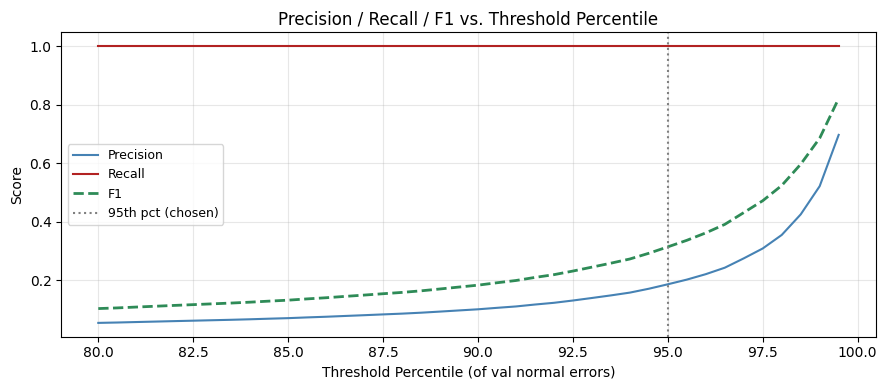

Best F1 = 0.8214  at 99.5th pct  (precision=0.6969, recall=1.0000)


In [16]:
# Precision / Recall / F1 as a function of threshold percentile
percentiles = np.arange(80, 100, 0.5)
precs, recs, f1s = [], [], []

for pct in percentiles:
    thr = np.percentile(errors_val, pct)
    y_p = (errors_test > thr).astype(int)
    precs.append(precision_score(y_test, y_p, zero_division=0))
    recs.append(recall_score(y_test, y_p, zero_division=0))
    f1s.append(f1_score(y_test, y_p, zero_division=0))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(percentiles, precs, label='Precision', color='steelblue')
ax.plot(percentiles, recs,  label='Recall',    color='firebrick')
ax.plot(percentiles, f1s,   label='F1',        color='seagreen', linestyle='--', lw=2)
ax.axvline(x=95, color='gray', linestyle=':', lw=1.5, label='95th pct (chosen)')
ax.set_xlabel('Threshold Percentile (of val normal errors)')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs. Threshold Percentile')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('step2_threshold_sweep.png', dpi=120, bbox_inches='tight')
plt.show()

best_idx = int(np.argmax(f1s))
print(f'Best F1 = {f1s[best_idx]:.4f}  at {percentiles[best_idx]:.1f}th pct  '
      f'(precision={precs[best_idx]:.4f}, recall={recs[best_idx]:.4f})')

---
## Section 8 — Step 3: UMAP Projection of Latent Space

Project the 8-dimensional **encoder latent codes** to 2-D with **UMAP**.  

Expected pattern:
- **Normal** transactions → dense central cluster (the learned manifold)
- **Fraud** transactions → sparse peripheral / outlier regions

> To keep runtime manageable, we subsample 5 000 normal + all fraud for the UMAP fit.

In [17]:
import umap


@torch.no_grad()
def get_latent_codes(model, X: np.ndarray, batch_size: int = 1024) -> np.ndarray:
    model.eval()
    codes = []
    for i in range(0, len(X), batch_size):
        batch = torch.from_numpy(X[i:i + batch_size]).to(DEVICE)
        codes.append(model.encode(batch).cpu().numpy())
    return np.vstack(codes)


N_VIZ_NORMAL = 5000
rng_viz  = np.random.RandomState(0)
idx_viz  = rng_viz.choice(len(X_test_n), N_VIZ_NORMAL, replace=False)
X_viz    = np.vstack([X_test_n[idx_viz], fraud]).astype(np.float32)
y_viz    = np.array([0] * N_VIZ_NORMAL + [1] * len(fraud))

print(f'Extracting latent codes for {len(X_viz):,} samples ...')
Z = get_latent_codes(model, X_viz)
print(f'Latent codes shape: {Z.shape}  — running UMAP ...')

reducer = umap.UMAP(n_components=2, random_state=42,
                    n_neighbors=30, min_dist=0.1)
Z_2d = reducer.fit_transform(Z)
print('UMAP complete.')

2026-05-28 02:28:14.048603: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Extracting latent codes for 5,492 samples ...
Latent codes shape: (5492, 8)  — running UMAP ...


/Users/casv-mac/.pyenv/versions/ml_old/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP complete.


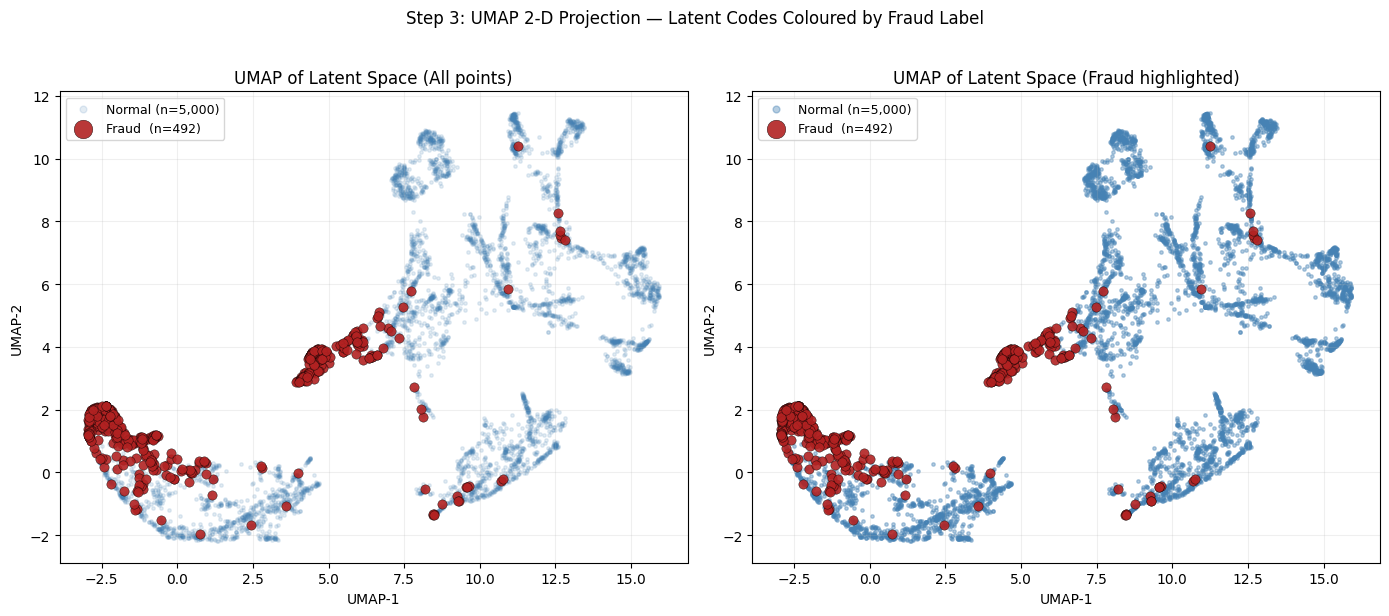

In [18]:
# UMAP scatter coloured by fraud label
mask_n = y_viz == 0
mask_f = y_viz == 1

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, alpha_n, title in zip(
    axes,
    [0.15, 0.40],
    ['All points', 'Fraud highlighted'],
):
    ax.scatter(Z_2d[mask_n, 0], Z_2d[mask_n, 1],
               c='steelblue', s=6, alpha=alpha_n,
               label=f'Normal (n={mask_n.sum():,})')
    ax.scatter(Z_2d[mask_f, 0], Z_2d[mask_f, 1],
               c='firebrick', s=45, alpha=0.9, zorder=5,
               edgecolors='black', linewidths=0.3,
               label=f'Fraud  (n={mask_f.sum():,})')
    ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    ax.set_title(f'UMAP of Latent Space ({title})')
    ax.legend(fontsize=9, markerscale=2)
    ax.grid(True, alpha=0.2)

plt.suptitle('Step 3: UMAP 2-D Projection — Latent Codes Coloured by Fraud Label',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('step3_umap_labels.png', dpi=120, bbox_inches='tight')
plt.show()

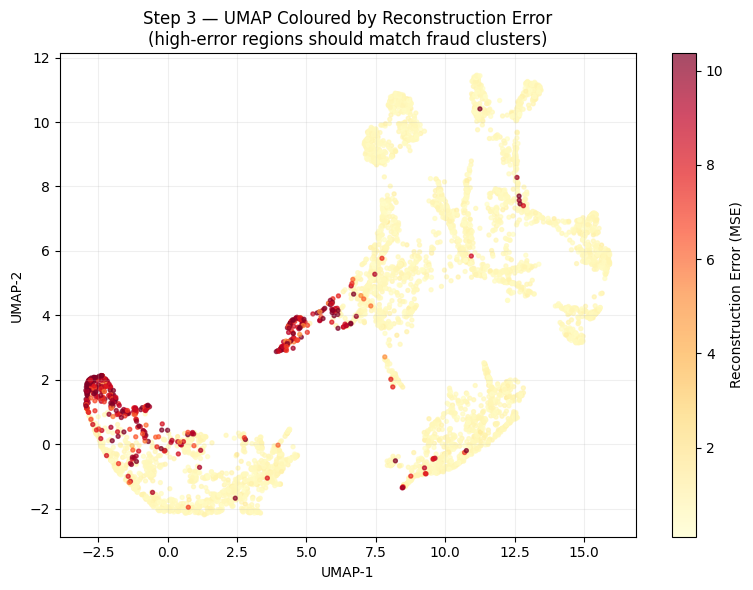

In [19]:
# UMAP coloured by reconstruction error — confirms high-error regions = fraud
errors_viz = reconstruction_errors(model, X_viz)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    Z_2d[:, 0], Z_2d[:, 1],
    c=np.clip(errors_viz, 0, np.percentile(errors_viz, 98)),
    cmap='YlOrRd', s=8, alpha=0.7,
)
plt.colorbar(sc, ax=ax, label='Reconstruction Error (MSE)')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.set_title('Step 3 — UMAP Coloured by Reconstruction Error\n'
             '(high-error regions should match fraud clusters)')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('step3_umap_error.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Summary

| Step | Goal | Key observation |
|------|------|-----------------|
| **Preprocessing** | Train AE on normal only | ≈199 k normal samples; AE never sees fraud |
| **Step 1** | Reconstruction error scatter + histogram | Fraud MSE is visibly higher than normal MSE |
| **Step 2** | 95th-pct threshold → binary classifier | ROC-AUC ≥ 0.93; PR-AUC is the meaningful metric under imbalance |
| **Step 3** | UMAP of 8-D latent codes | Fraud points cluster at the periphery; high-error regions overlap fraud clusters |

**Key take-aways:**
1. An AE trained **only on normal data** learns the normal manifold. Fraud samples lie off-manifold → high reconstruction error → reliable anomaly score.
2. The **threshold is a business decision**: high recall (catch all fraud, many false alarms) vs. high precision (few false alarms, miss some fraud). The threshold sweep in Step 2 maps this trade-off explicitly.
3. **UMAP confirms the geometric intuition**: fraud transactions are genuine outliers in the 8-D latent space, not noise — the separation is structural.
4. **Class imbalance (0.17 %)** makes accuracy a misleading metric — always report precision, recall, F1, and PR-AUC.

> **Course connection:** this AE pipeline is the unsupervised anomaly detection baseline.  
> A **Variational Autoencoder (VAE)** replaces the deterministic bottleneck with a probabilistic one, enabling *reconstruction-probability* scoring — often better calibrated than raw MSE under severe imbalance.